In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("banknifty.csv")
df.head()

,Date,bnf,axis_bank,bandhan_bank,au_bank,sbi_bank,bob_bank,idfc_bank,federal_bank,kotak_bank,hdfc_bank,icici_bank,pnb_bank,indusind_bank
0,2019-01-01,27231.083902,618.546030,534.976412,309.155397,269.647776,105.894305,43.258412,88.442464,249.622001,499.590664,348.786163,72.929236,1537.001925
1,2019-01-02,27296.682170,619.640096,535.460651,305.627042,271.097947,109.484698,43.059064,87.923598,248.407754,503.148028,348.786181,73.810707,1525.090081
2,2019-01-03,27181.284539,618.048677,533.523988,308.211205,267.381827,107.623011,42.510861,89.904712,246.835168,498.780562,352.163062,72.465316,1511.064953
3,2019-01-04,26999.385085,608.699314,517.305353,308.608777,264.753329,106.736503,42.959389,87.970770,246.437066,496.678989,349.123861,72.372531,1499.345439
4,2019-01-07,27378.333126,622.623826,522.872909,310.596612,272.865420,108.598189,45.849931,89.857549,249.014896,499.602373,354.575119,76.501471,1499.537633


In [3]:
df.columns

Index(['Date', 'bnf', 'axis_bank', 'bandhan_bank', 'au_bank', 'sbi_bank',
       'bob_bank', 'idfc_bank', 'federal_bank', 'kotak_bank', 'hdfc_bank',
       'icici_bank', 'pnb_bank', 'indusind_bank'],
      dtype='object')

In [4]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1825 non-null   object 
 1   bnf            1825 non-null   float64
 2   axis_bank      1825 non-null   float64
 3   bandhan_bank   1825 non-null   float64
 4   au_bank        1825 non-null   float64
 5   sbi_bank       1825 non-null   float64
 6   bob_bank       1825 non-null   float64
 7   idfc_bank      1825 non-null   float64
 8   federal_bank   1825 non-null   float64
 9   kotak_bank     1825 non-null   float64
 10  hdfc_bank      1825 non-null   float64
 11  icici_bank     1825 non-null   float64
 12  pnb_bank       1825 non-null   float64
 13  indusind_bank  1825 non-null   float64
dtypes: float64(13), object(1)
memory usage: 199.7+ KB
None


In [5]:
print(df.describe())

                bnf    axis_bank  bandhan_bank      au_bank     sbi_bank  \
count   1825.000000  1825.000000   1825.000000  1825.000000  1825.000000   
mean   40283.120318   874.891872    277.850485   585.585112   522.715023   
std    10893.678549   248.147941    112.765324   185.095568   247.517233   
min    16759.754383   292.279635    128.327701   189.054538   137.724281   
25%    31414.285584   711.094188    191.000000   447.263267   303.365084   
50%    39517.392801   804.668309    248.147071   604.029315   489.847096   
75%    49336.101562  1089.069273    318.536793   694.143938   743.403801   
max    61660.851562  1403.000000    605.419065  1062.900024  1210.186291   

          bob_bank    idfc_bank  federal_bank   kotak_bank    hdfc_bank  \
count  1825.000000  1825.000000   1825.000000  1825.000000  1825.000000   
mean    149.285553    57.007641    129.649760   351.765242   723.536303   
std      80.562187    18.232933     62.831793    48.201526   142.562192   
min      32.047

In [6]:
df.isnull().sum()

Date             0
bnf              0
axis_bank        0
bandhan_bank     0
au_bank          0
sbi_bank         0
bob_bank         0
idfc_bank        0
federal_bank     0
kotak_bank       0
hdfc_bank        0
icici_bank       0
pnb_bank         0
indusind_bank    0
dtype: int64

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.dtypes

In [7]:
print(df.index)
print(type(df))

RangeIndex(start=0, stop=1825, step=1)
<class 'pandas.core.frame.DataFrame'>


In [8]:
stocks_col = [col for col in df.columns if col != 'Date']
growth = {}

for col in stocks_col:
    first_price = df[col].iloc[0]
    last_price = df[col].iloc[-1]

    growth_perc = ((last_price-first_price)/ first_price) * 100
    growth[col] = growth_perc

growth_df = pd.DataFrame(growth.items(), columns=['bank', 'growth (%)'])
growth_df = growth_df.sort_values(by='growth (%)', ascending=False)
print(growth_df)

             bank  growth (%)
10     icici_bank  265.582156
4        sbi_bank  258.912653
7    federal_bank  230.158147
3         au_bank  225.079236
5        bob_bank  157.379269
1       axis_bank  109.539778
0             bnf  101.050759
6       idfc_bank   66.002388
8      kotak_bank   55.775535
9       hdfc_bank   49.332252
11       pnb_bank   46.374768
12  indusind_bank  -39.453558
2    bandhan_bank  -61.506715


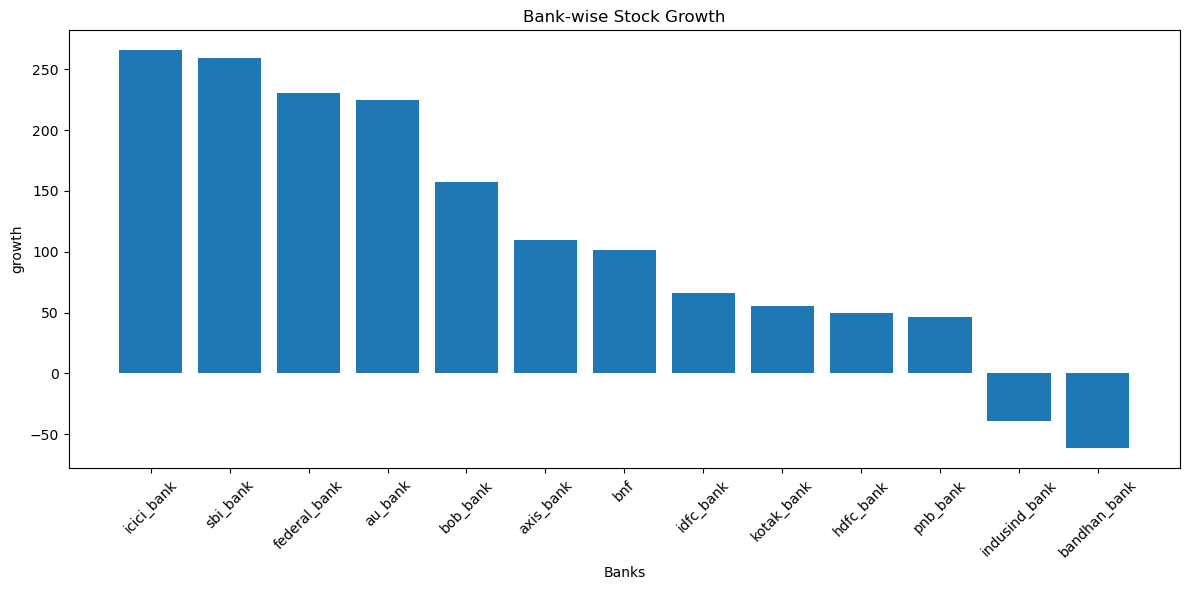

In [9]:
plt.figure(figsize=(12, 6))
plt.bar(growth_df['bank'], growth_df['growth (%)'])

plt.title('Bank-wise Stock Growth')
plt.xlabel('Banks')
plt.ylabel('growth')
plt.xticks(rotation =45)
plt.tight_layout()
plt.show()



In [10]:
#From this we know that ICICI bank is best performer and bandhan_bank is worst performer.

volatility 

In [12]:
daily_return = df.drop(columns=["Date"]).pct_change()
daily_return.head()

volatility = daily_return.std()

volatility_df = pd.DataFrame(volatility, columns=['volatility'])
print(volatility_df)

               volatility
bnf              0.015543
axis_bank        0.020994
bandhan_bank     0.030777
au_bank          0.025351
sbi_bank         0.020865
bob_bank         0.026025
idfc_bank        0.026131
federal_bank     0.023234
kotak_bank       0.017430
hdfc_bank        0.017086
icici_bank       0.018707
pnb_bank         0.026003
indusind_bank    0.030862


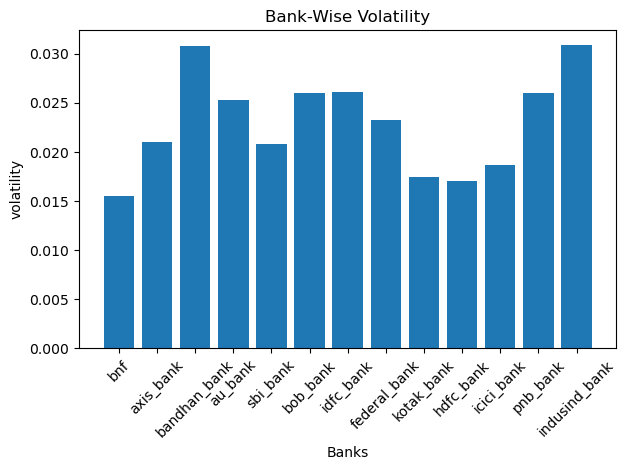

In [13]:
plt.Figure(figsize=(12,6))
plt.bar(volatility_df.index, volatility_df['volatility'])
plt.title("Bank-Wise Volatility")
plt.xlabel('Banks')
plt.ylabel('volatility')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
#indusind bank have high volatility and bnf bank have low volatility

correlation matrix

In [18]:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

                    bnf  axis_bank  bandhan_bank   au_bank  sbi_bank  \
bnf            1.000000   0.964342     -0.697959  0.865105  0.969185   
axis_bank      0.964342   1.000000     -0.583381  0.803690  0.948449   
bandhan_bank  -0.697959  -0.583381      1.000000 -0.658669 -0.716988   
au_bank        0.865105   0.803690     -0.658669  1.000000  0.850570   
sbi_bank       0.969185   0.948449     -0.716988  0.850570  1.000000   
bob_bank       0.940116   0.961373     -0.652172  0.753998  0.951615   
idfc_bank      0.834228   0.863576     -0.535353  0.736256  0.765837   
federal_bank   0.935245   0.939044     -0.633982  0.805950  0.969549   
kotak_bank     0.796039   0.672206     -0.542939  0.798893  0.701400   
hdfc_bank      0.935754   0.838616     -0.690161  0.826314  0.851765   
icici_bank     0.980230   0.919736     -0.782393  0.826817  0.958220   
pnb_bank       0.788258   0.870163     -0.415248  0.510012  0.817287   
indusind_bank  0.149253   0.308517      0.329955  0.029606  0.07

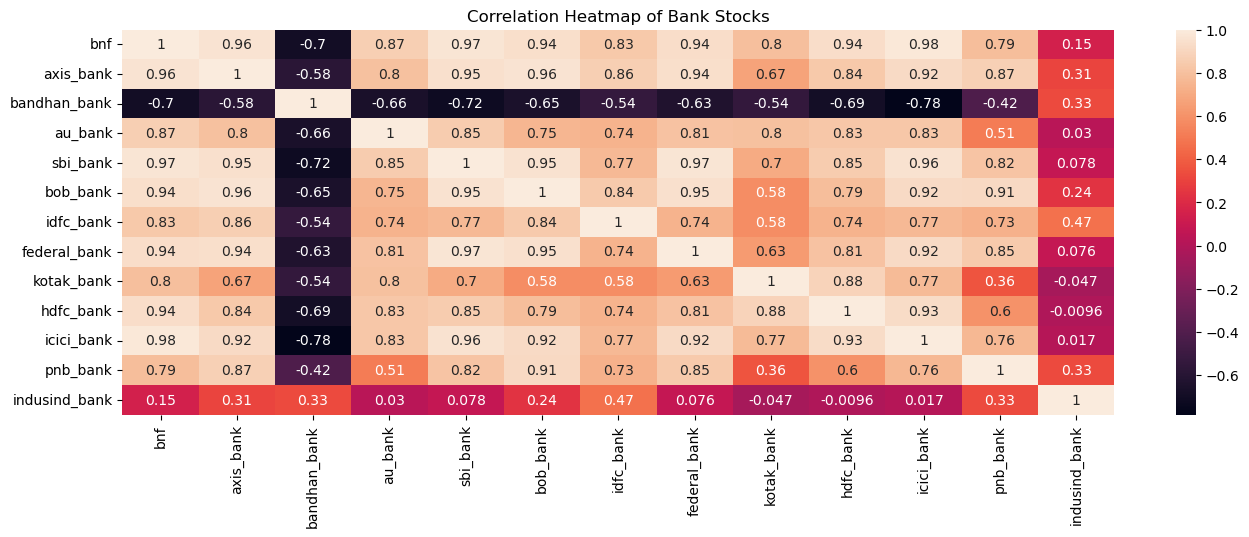

In [19]:
plt.figure(figsize=(16, 5))
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Heatmap of Bank Stocks")
plt.show()

Historical Trend Analysis

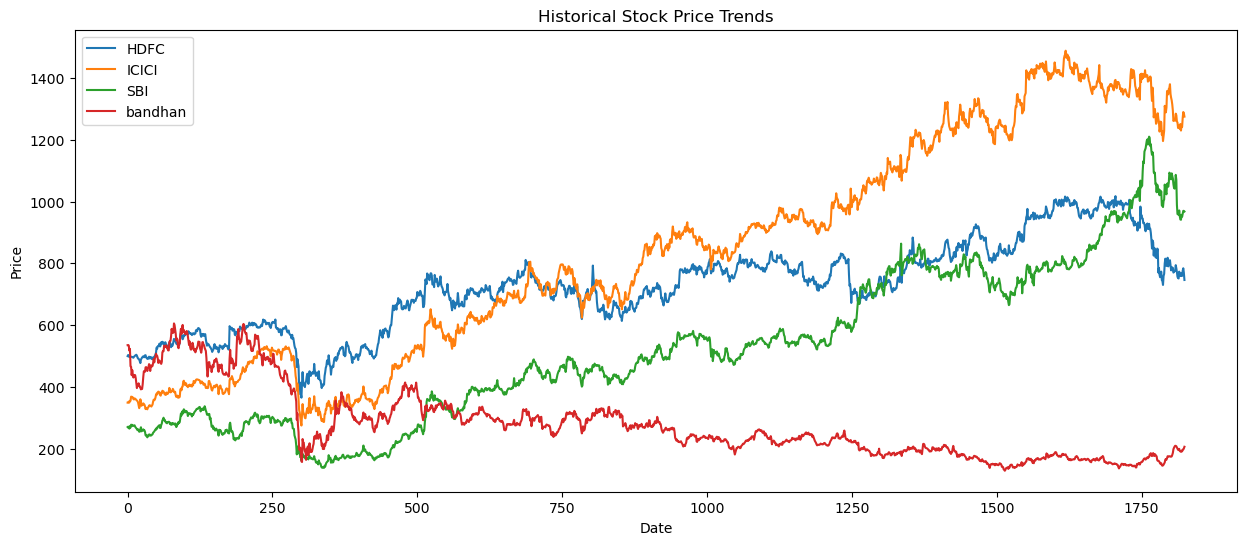

In [20]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['hdfc_bank'], label='HDFC')
plt.plot(df.index,df['icici_bank'], label='ICICI')
plt.plot(df.index, df['sbi_bank'], label='SBI')
plt.plot(df.index, df['bandhan_bank'], label='bandhan')

plt.title('Historical Stock Price Trends')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

From above graph its clear ICICI stock grows steadily...but Bandhan bank stock crashes

In [21]:
#Rolling Means

In [22]:
rolling_means= pd.DataFrame()
for col in df.columns:
    rolling_means[col] = df[col].rolling(window=30).mean()
print(rolling_means)

DataError: No numeric types to aggregate

In [23]:
rolling_volatility = pd.DataFrame()
for col in df.columns:
    rolling_volatility[col] = df[col].rolling(window=30).std()
print(rolling_volatility)

DataError: No numeric types to aggregate

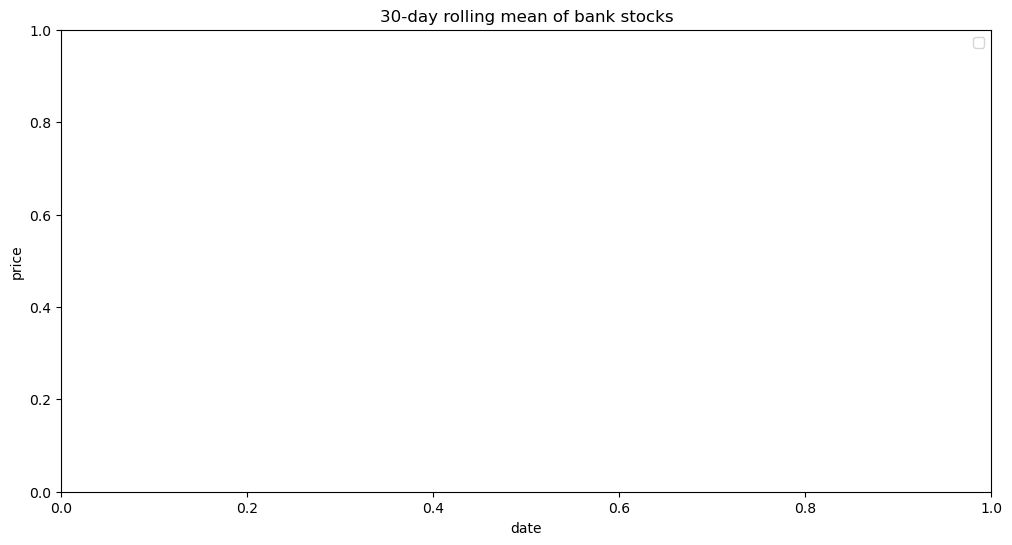

In [24]:
plt.figure(figsize=(12,6))
for col in rolling_means.columns:
    plt.plot(rolling_means.index, rolling_means[col], label=col)

plt.title('30-day rolling mean of bank stocks')
plt.xlabel('date')
plt.ylabel('price')
plt.legend()
plt.show()

In [25]:
plt.figure(figsize=(18,15))
for i, col in enumerate(rolling_volatility.columns, 1):
  plt.subplot(5,4, i)
  plt.plot(rolling_volatility.index, rolling_volatility[col], label=col)

  plt.title("30-Day Rolling Volatility of Bank Stocks")
  plt.xlabel("Date")
  plt.ylabel("Volatility")
  plt.legend()
  plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1800x1500 with 0 Axes>

In [26]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib 
import os

In [27]:
df.rename(columns={"index": "Date"}, inplace=True)

In [28]:
print(df.columns.tolist())

['Date', 'bnf', 'axis_bank', 'bandhan_bank', 'au_bank', 'sbi_bank', 'bob_bank', 'idfc_bank', 'federal_bank', 'kotak_bank', 'hdfc_bank', 'icici_bank', 'pnb_bank', 'indusind_bank']


In [29]:
bank_columns = df.columns.drop("Date")
prophet_data = {}
for bank in bank_columns:
    temp_df = df[["Date", bank]].copy()
    temp_df.columns = ["ds", "y"]
    temp_df["ds"] = pd.to_datetime(temp_df["ds"])
    temp_df = temp_df.dropna()
    prophet_data[bank] = temp_df

print("Total banks prepared:", len(prophet_data))
print(prophet_data["hdfc_bank"].head())

Total banks prepared: 13
          ds           y
0 2019-01-01  499.590664
1 2019-01-02  503.148028
2 2019-01-03  498.780562
3 2019-01-04  496.678989
4 2019-01-07  499.602373


In [30]:
train_data ={}
test_data = {}

for bank, data in prophet_data.items():
    split_index = int(len(data) * 0.8)

    train_data[bank] = data.iloc[:split_index]
    test_data[bank] = data.iloc[split_index:]

print("Train size:", len(train_data["hdfc_bank"]))
print("Test size:", len(test_data["hdfc_bank"]))

Train size: 1460
Test size: 365


In [31]:
models = {}
for bank in train_data.keys():
    model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    model.fit(train_data[bank])
    models[bank] = model
print("total models trained:", len(models))


19:49:25 - cmdstanpy - INFO - Chain [1] start processing
19:49:26 - cmdstanpy - INFO - Chain [1] done processing
19:49:26 - cmdstanpy - INFO - Chain [1] start processing
19:49:26 - cmdstanpy - INFO - Chain [1] done processing
19:49:27 - cmdstanpy - INFO - Chain [1] start processing
19:49:27 - cmdstanpy - INFO - Chain [1] done processing
19:49:27 - cmdstanpy - INFO - Chain [1] start processing
19:49:28 - cmdstanpy - INFO - Chain [1] done processing
19:49:28 - cmdstanpy - INFO - Chain [1] start processing
19:49:29 - cmdstanpy - INFO - Chain [1] done processing
19:49:29 - cmdstanpy - INFO - Chain [1] start processing
19:49:30 - cmdstanpy - INFO - Chain [1] done processing
19:49:30 - cmdstanpy - INFO - Chain [1] start processing
19:49:31 - cmdstanpy - INFO - Chain [1] done processing
19:49:31 - cmdstanpy - INFO - Chain [1] start processing
19:49:32 - cmdstanpy - INFO - Chain [1] done processing
19:49:32 - cmdstanpy - INFO - Chain [1] start processing
19:49:33 - cmdstanpy - INFO - Chain [1]

total models trained: 13


In [32]:
predictions ={}
for bank in models.keys():
    future = test_data[bank][["ds"]]
    forecast = models[bank].predict(future)
    predictions[bank] = forecast

print(predictions["hdfc_bank"][["ds", "yhat"]].head())

          ds        yhat
0 2024-12-04  861.764243
1 2024-12-05  861.079376
2 2024-12-06  859.291697
3 2024-12-09  859.376630
4 2024-12-10  858.038701


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

result =[]
for bank in train_data.keys():
    actual = test_data[bank]["y"].values
    predicted = predictions[bank]["yhat"].values

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual-predicted)/ actual)) * 100
    result.append([bank, mae, rmse, mape])

    result_df= pd.DataFrame(result, columns=["bank", "mae", "rmse", "mape"])
    result_df = result_df.sort_values(by ="rmse")
    print(result_df)

  bank          mae         rmse      mape
0  bnf  3142.957613  4015.581472  5.900923
        bank          mae         rmse       mape
1  axis_bank   216.567370   226.280580  18.874215
0        bnf  3142.957613  4015.581472   5.900923
           bank          mae         rmse       mape
2  bandhan_bank    23.324281    30.464416  14.075781
1     axis_bank   216.567370   226.280580  18.874215
0           bnf  3142.957613  4015.581472   5.900923
           bank          mae         rmse       mape
2  bandhan_bank    23.324281    30.464416  14.075781
1     axis_bank   216.567370   226.280580  18.874215
3       au_bank   232.162737   278.386011  26.843136
0           bnf  3142.957613  4015.581472   5.900923
           bank          mae         rmse       mape
2  bandhan_bank    23.324281    30.464416  14.075781
4      sbi_bank   173.884444   185.820537  20.996396
1     axis_bank   216.567370   226.280580  18.874215
3       au_bank   232.162737   278.386011  26.843136
0           bnf  3142.

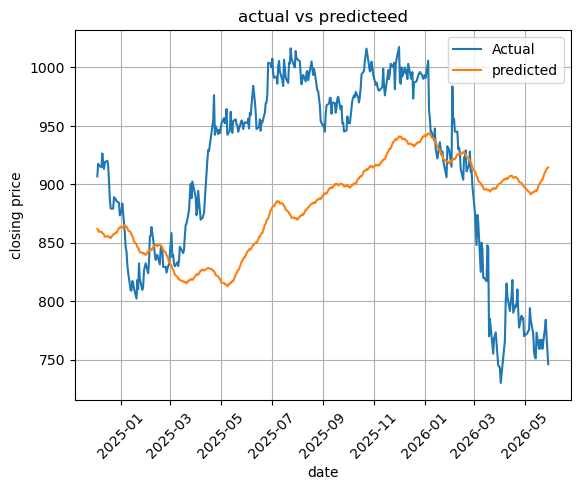

In [43]:
bank = "hdfc_bank"
plt.Figure(figsize=(12, 6))
plt.plot(test_data[bank]["ds"], test_data[bank]["y"], label="Actual")
plt.plot(predictions[bank]["ds"], predictions[bank]['yhat'], label='predicted')

plt.title("actual vs predicteed")
plt.xlabel("date")
plt.ylabel("closing price")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [44]:
future_forecast = {}
for bank in models.keys():
    future= models[bank].make_future_dataframe(periods=30)
    forecast = models[bank].predict(future)
    future_forecast[bank] = forecast


In [45]:
bank = "hdfc_bank"
future_forecast[bank][["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30)


,ds,yhat,yhat_lower,yhat_upper
1460,2024-12-04,861.764243,825.401034,895.400577
1461,2024-12-05,861.079376,822.723334,897.793743
1462,2024-12-06,859.291697,821.651362,894.761032
1463,2024-12-07,866.235612,829.069165,904.731611
1464,2024-12-08,865.630875,827.574387,901.744660
1465,2024-12-09,859.376630,823.023392,894.697675
1466,2024-12-10,858.038701,819.836313,894.915887
1467,2024-12-11,857.844728,819.264493,894.576759
1468,2024-12-12,856.901812,819.002028,893.975093
1469,2024-12-13,855.011476,814.689826,889.341222


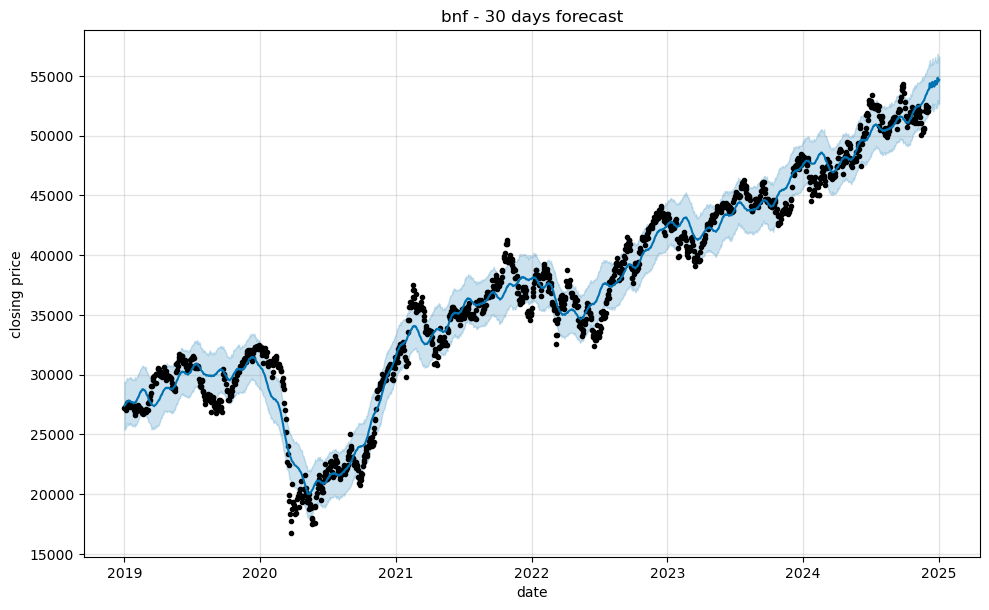

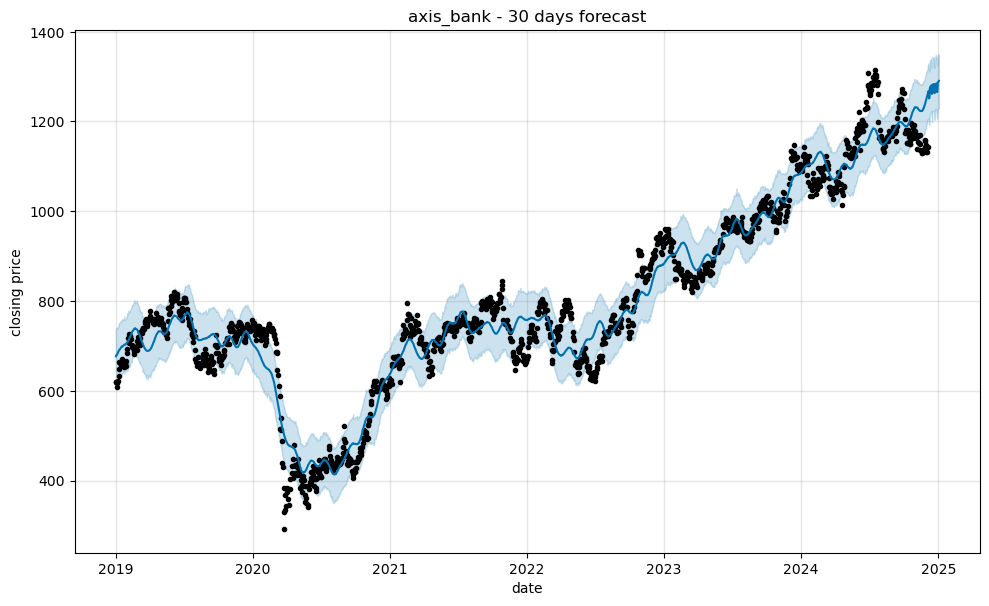

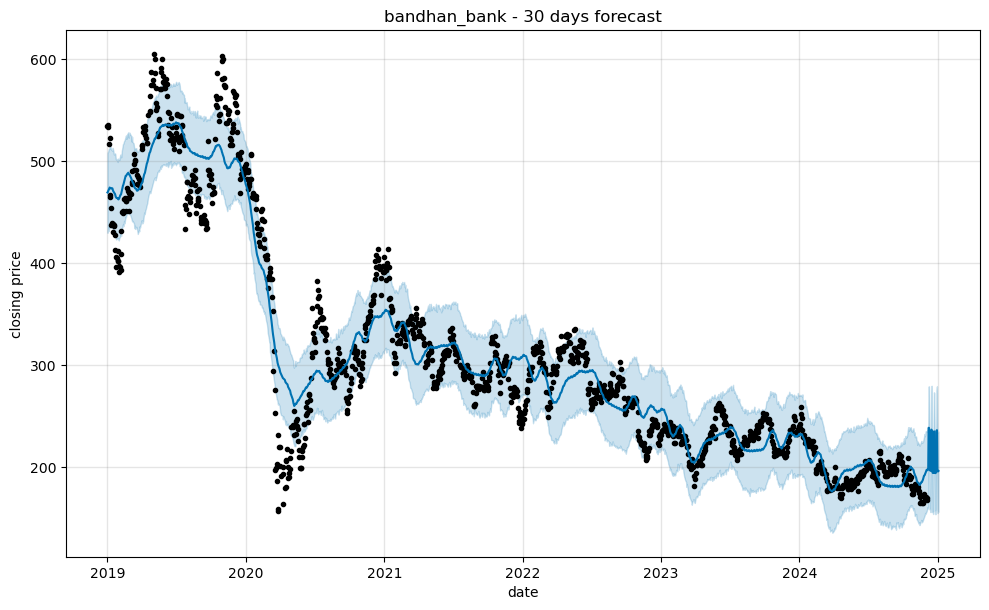

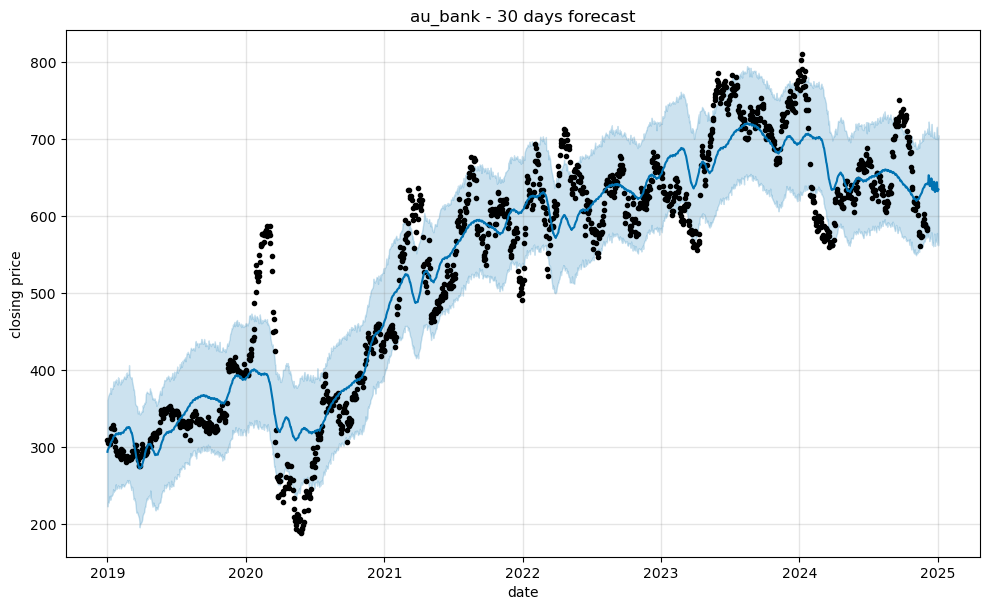

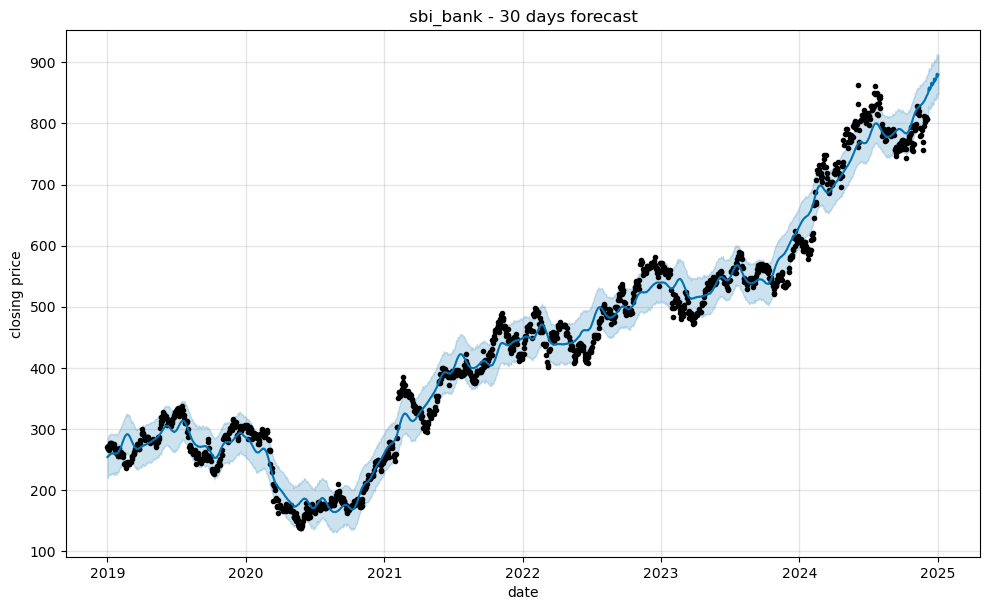

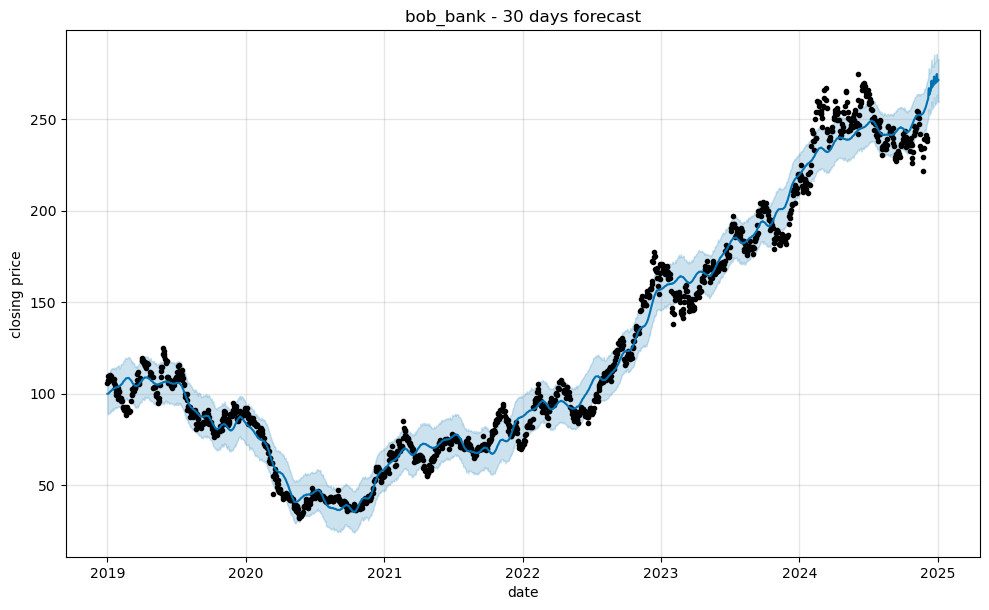

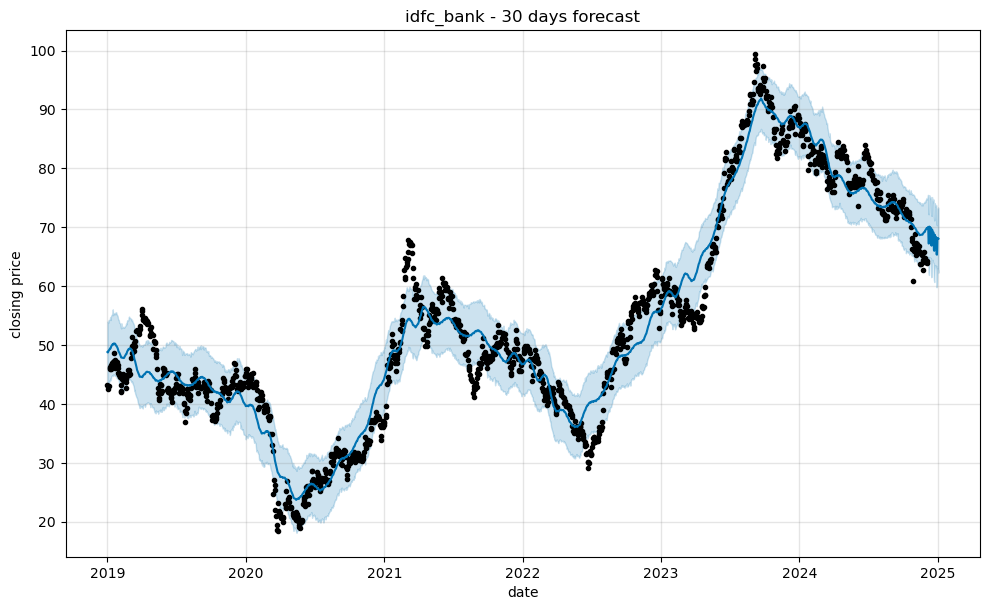

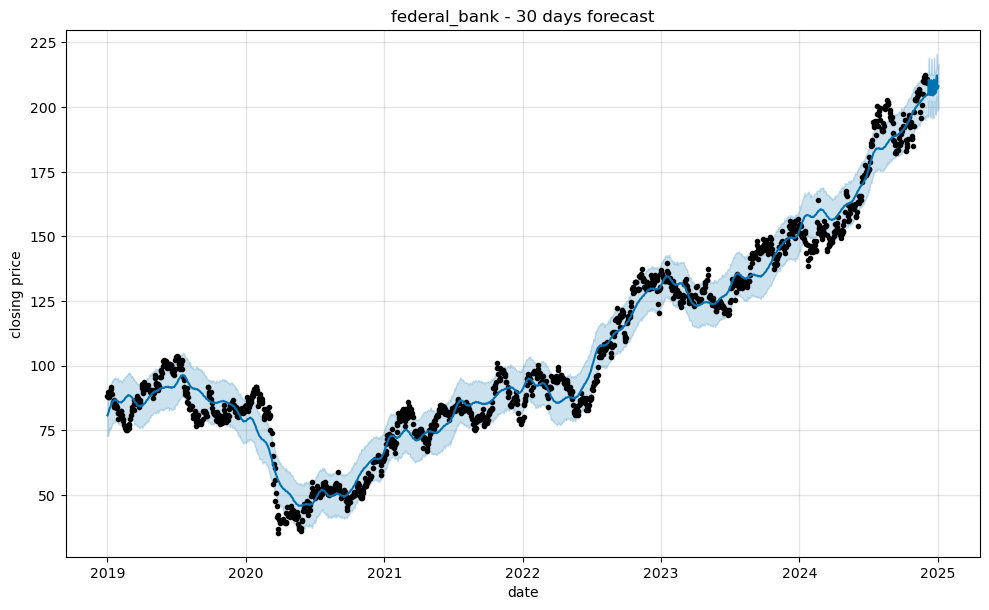

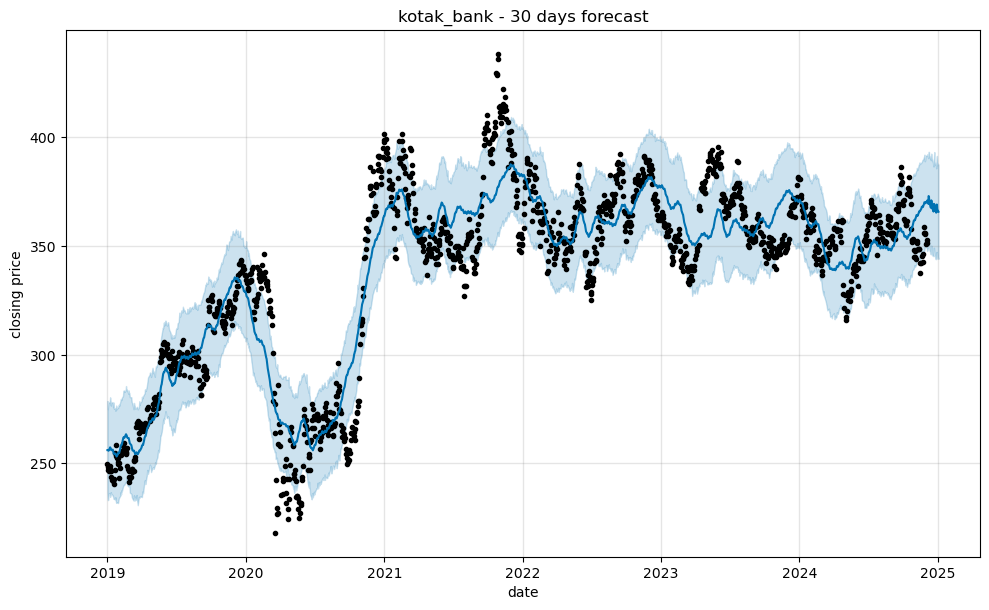

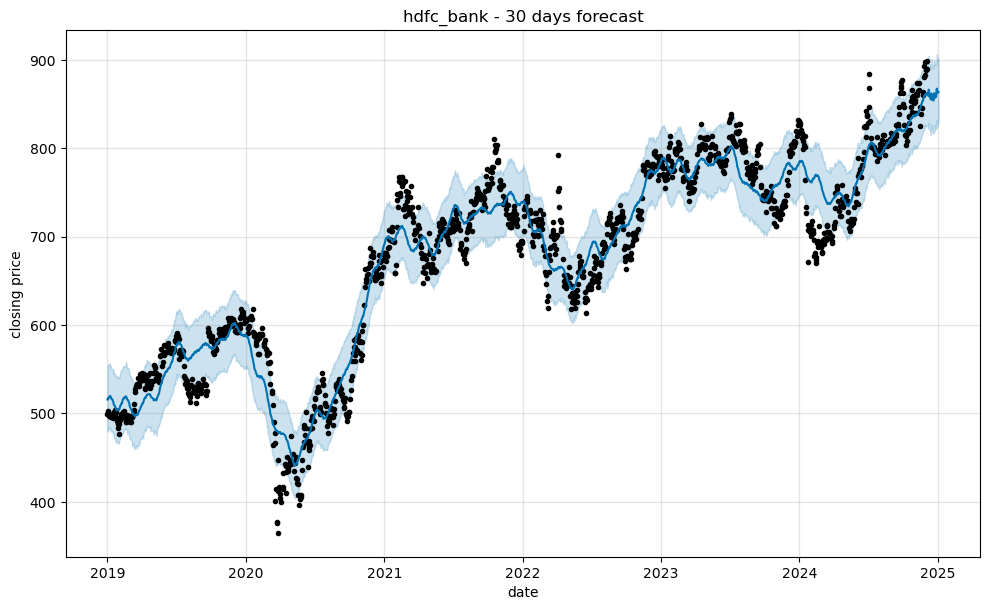

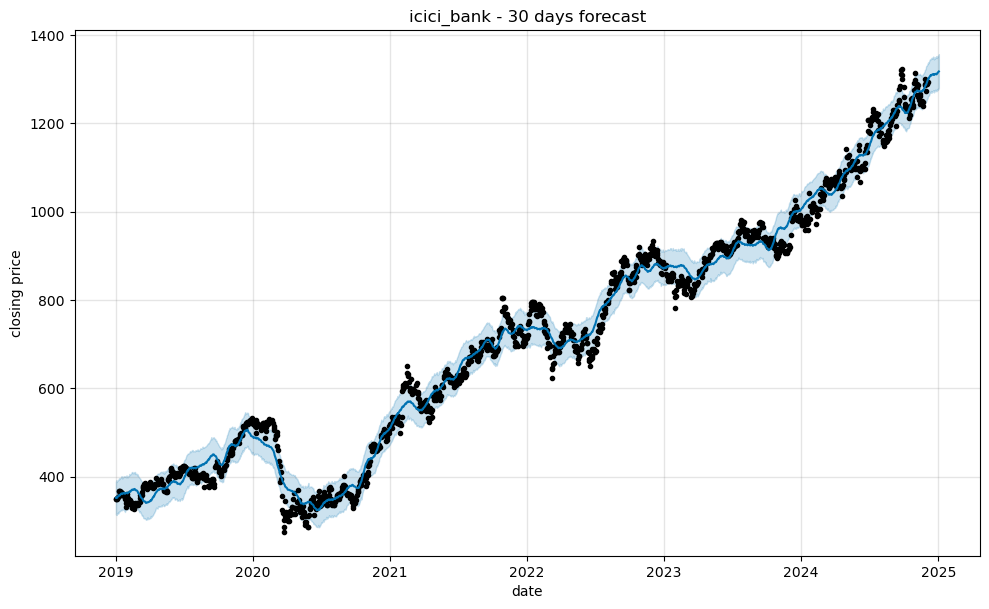

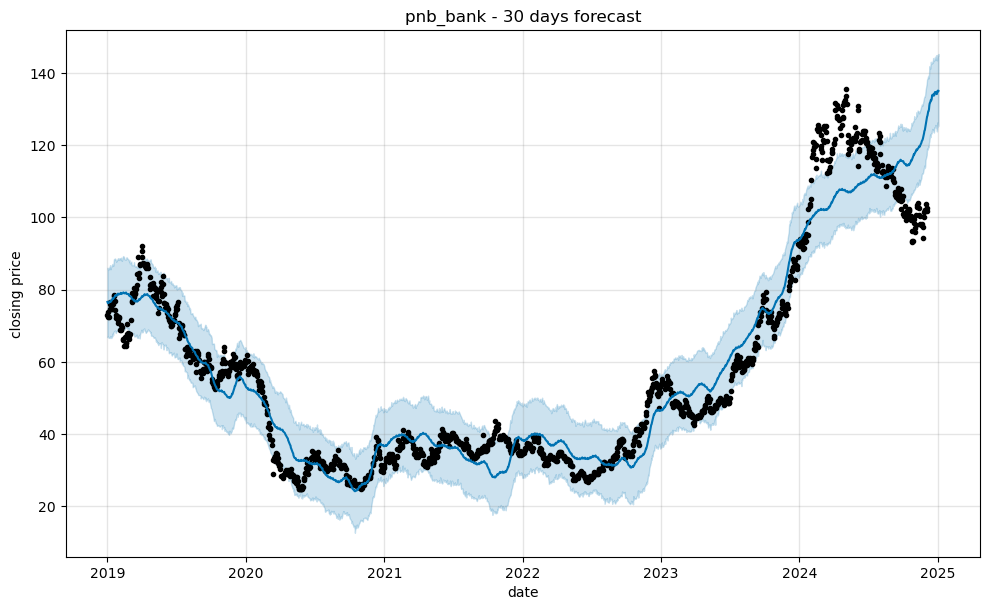

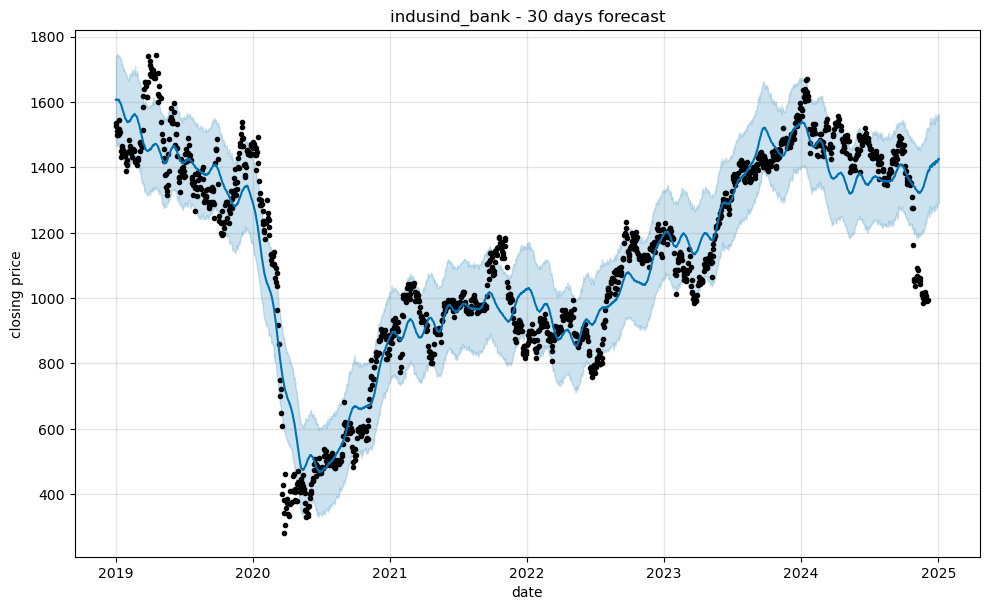

In [47]:
for bank in models.keys():
    fig = models[bank].plot(future_forecast[bank])
    plt.title(f"{bank} - 30 days forecast")
    plt.xlabel("date")
    plt.ylabel("closing price")
    plt.grid(True)
    plt.show()

In [48]:
os.makedirs("saved_models", exist_ok=True)

for bank, model in models.items():
    model_path = f"saved_models/{bank}.pkl"
    joblib.dump(model, model_path)
print("all prophet models saved successfully")

all prophet models saved successfully
